# Precision Multi-Class Irrigation Intelligence

**Objective:**  
Classify the `Irrigation_Need` of a crop field into three categories:

- **Low**
- **Medium**
- **High**

This project implements an end-to-end machine learning pipeline for multi-class irrigation-need prediction, covering data preprocessing, feature encoding, class imbalance handling, model training, model comparison, evaluation, threshold analysis, feature importance, model serialization, and Flask REST API deployment.

## Methodology

The project follows a complete machine-learning pipeline for multi-class irrigation-need prediction:

- **Data Preprocessing:** Cleaning, target encoding, and feature preparation.
- **Stratified Data Splitting:** Maintaining class proportions while dividing the dataset into training, validation, and test sets.
- **Feature Encoding:** Categorical features are converted using One-Hot Encoding.
- **Class Imbalance Handling:** The training data is balanced using `SMOTE`.
- **Model Training:** Multiple classification algorithms are trained and compared:
  - CatBoost
  - XGBoost
  - LightGBM
  - Logistic Regression
- **Model Evaluation:** Models are evaluated using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Macro F1-score
  - Class-wise F1-score
  - Confusion Matrix
  - ROC-AUC
  - Precision-Recall curves
- **Model Validation:** Training, validation, and test performance are compared to identify potential:
  - Overfitting
  - Underfitting
  - Generalization gaps
- **Final Model Selection:** The model with the strongest overall performance on the final evaluation is selected for deployment.
- **Custom Threshold Analysis:** Different probability thresholds are evaluated for the High irrigation-need class.
- **Feature Importance Analysis:** The most important features from the final XGBoost model are identified and visualized.

## Data Preprocessing

The dataset is loaded using Pandas and the unnecessary `id` column is removed before model development.

The target variable is:

```text
Irrigation_Need

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score

from sklearn.metrics import (
    f1_score,
    classification_report,
    cohen_kappa_score,
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


In [25]:
df = pd.read_csv('train.csv')

if 'id' in df.columns:
    df = df.drop(columns=['id'])

targetColumn = 'Irrigation_Need'

features = df.drop(columns=[targetColumn])
target = df[targetColumn]

labelEncoder = LabelEncoder()

if target.dtype == 'object':
    target = labelEncoder.fit_transform(target)

print('Dataset shape:', df.shape)
print('Features shape:', features.shape)
print('Target shape:', target.shape)

display(df.head())

Dataset shape: (630000, 20)
Features shape: (630000, 19)
Target shape: (630000,)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


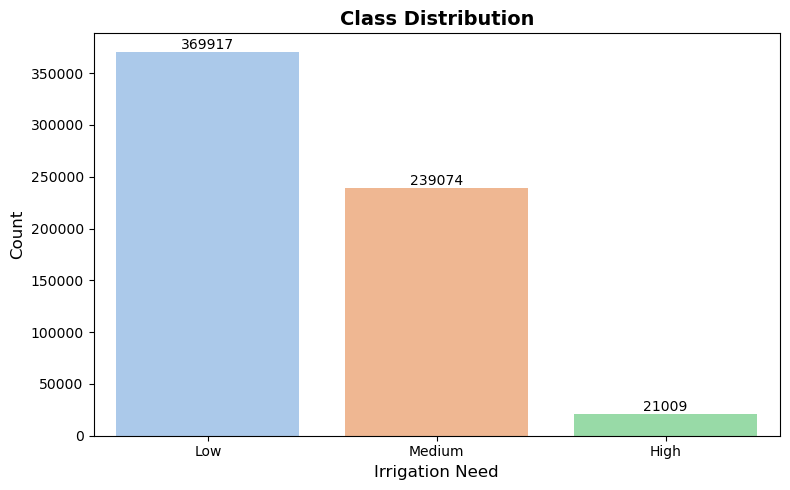


Class distribution:
 irrigationNeedLabel
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


In [26]:
plt.figure(figsize=(8, 5))

plotData = df.copy()

plotData['irrigationNeedLabel'] = plotData['Irrigation_Need'].astype(str)

ax = sns.countplot(
    x='irrigationNeedLabel',
    data=plotData,
    palette='pastel',
    order=['Low', 'Medium', 'High']
)

plt.title(
    'Class Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel(
    'Irrigation Need',
    fontsize=12
)

plt.ylabel(
    'Count',
    fontsize=12
)

for bar in ax.patches:
    ax.annotate(
        f'{int(bar.get_height())}',
        (
            bar.get_x() + bar.get_width() / 2.,
            bar.get_height()
        ),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

print(
    '\nClass distribution:\n',
    plotData['irrigationNeedLabel'].value_counts()
)

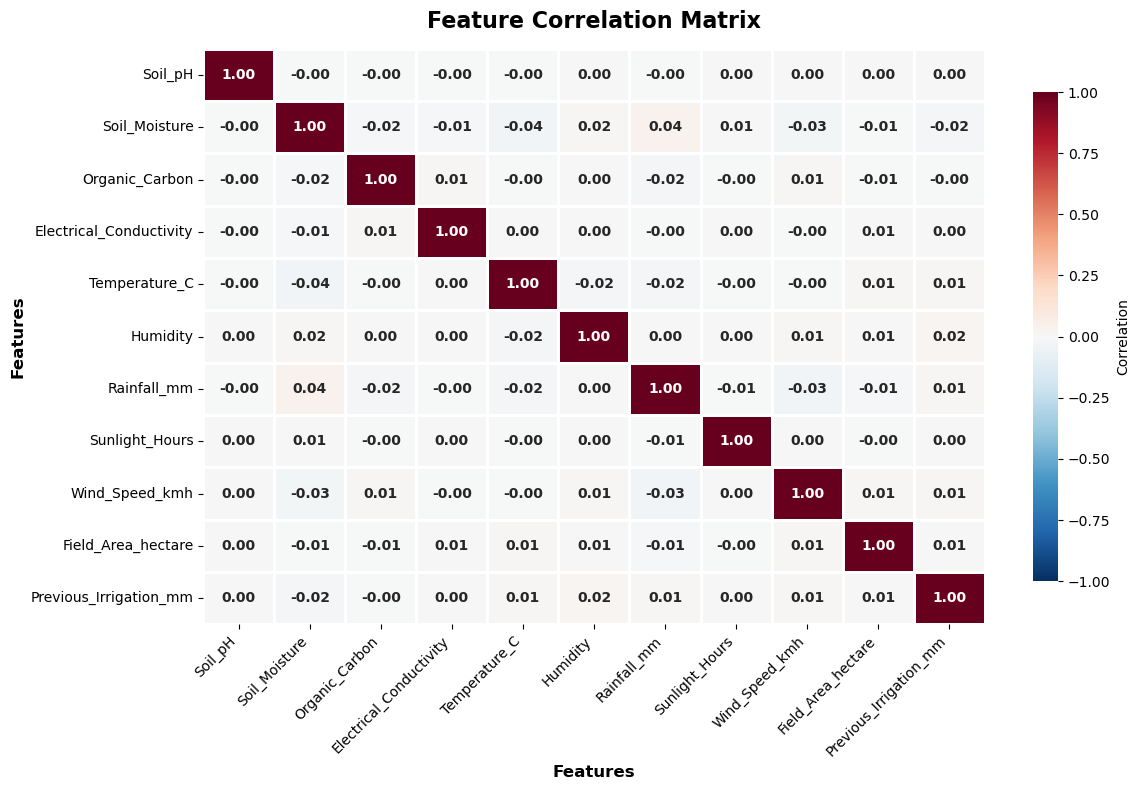

In [33]:
numericColumns = features.select_dtypes(
    include=[np.number]
).columns.tolist()

plt.figure(figsize=(12, 8))

sns.heatmap(
    features[numericColumns].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.8,
    linecolor='white',
    annot_kws={
        'size': 10,
        'weight': 'bold'
    },
    cbar_kws={
        'shrink': 0.85,
        'label': 'Correlation'
    }
)

plt.title(
    'Feature Correlation Matrix',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Features',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Features',
    fontsize=12,
    fontweight='bold'
)

plt.xticks(
    rotation=45,
    ha='right',
    fontsize=10
)

plt.yticks(
    rotation=0,
    fontsize=10
)

plt.tight_layout()
plt.show()

In [34]:
XEncoded = pd.get_dummies(features, drop_first=True)

yEncoded = pd.Series(
    target,
    index=features.index,
    name='Irrigation_Need'
)

sssTest = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

for trainValIndex, testIndex in sssTest.split(
    XEncoded,
    yEncoded
):

    trainValFeatures = XEncoded.iloc[trainValIndex]
    testFeatures = XEncoded.iloc[testIndex]

    trainValTarget = yEncoded.iloc[trainValIndex]
    testTarget = yEncoded.iloc[testIndex]

sssValidation = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.1765,
    random_state=42
)

for trainIndex, validationIndex in sssValidation.split(
    trainValFeatures,
    trainValTarget
):

    trainFeatures = trainValFeatures.iloc[trainIndex]
    validationFeatures = trainValFeatures.iloc[validationIndex]

    trainTarget = trainValTarget.iloc[trainIndex]
    validationTarget = trainValTarget.iloc[validationIndex]

print("=" * 60)
print("FINAL DATA SPLIT")
print("=" * 60)

print(f"Train      : {trainFeatures.shape}")
print(f"Validation : {validationFeatures.shape}")
print(f"Test       : {testFeatures.shape}")

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

print("\nTrain:")
print(trainTarget.value_counts(normalize=True).sort_index())

print("\nValidation:")
print(validationTarget.value_counts(normalize=True).sort_index())

print("\nTest:")
print(testTarget.value_counts(normalize=True).sort_index())

trainIndices = set(trainFeatures.index)
validationIndices = set(validationFeatures.index)
testIndices = set(testFeatures.index)

print("\n" + "=" * 60)
print("DATA LEAKAGE CHECK")
print("=" * 60)

print(
    "Train ∩ Validation :",
    len(trainIndices & validationIndices)
)

print(
    "Train ∩ Test       :",
    len(trainIndices & testIndices)
)

print(
    "Validation ∩ Test  :",
    len(validationIndices & testIndices)
)

assert len(trainIndices & validationIndices) == 0
assert len(trainIndices & testIndices) == 0
assert len(validationIndices & testIndices) == 0

print("\nNo overlap between Train, Validation and Test sets.")
print("Stratified 70/15/15 split completed successfully.")

FINAL DATA SPLIT
Train      : (440984, 35)
Validation : (94516, 35)
Test       : (94500, 35)

TARGET DISTRIBUTION

Train:
Irrigation_Need
0    0.033348
1    0.587169
2    0.379483
Name: proportion, dtype: float64

Validation:
Irrigation_Need
0    0.033349
1    0.587170
2    0.379481
Name: proportion, dtype: float64

Test:
Irrigation_Need
0    0.033344
1    0.587175
2    0.379481
Name: proportion, dtype: float64

DATA LEAKAGE CHECK
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

No overlap between Train, Validation and Test sets.
Stratified 70/15/15 split completed successfully.


In [35]:
print("=" * 60)
print("CLASS DISTRIBUTION BEFORE RESAMPLING")
print("=" * 60)

classCounts = pd.Series(
    trainTarget
).value_counts().sort_index()

print(classCounts)

targetMapping = {
    0: 100000,
    2: 200000
}

smote = SMOTE(
    sampling_strategy=targetMapping,
    random_state=42,
    k_neighbors=5
)

trainFeaturesResampled, trainTargetResampled = smote.fit_resample(
    trainFeatures,
    trainTarget
)

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION AFTER MODERATE SMOTE")
print("=" * 60)

afterCounts = pd.Series(
    trainTargetResampled
).value_counts().sort_index()

print(afterCounts)

print("\n" + "=" * 60)
print("TRAINING DATA SIZE")
print("=" * 60)

print(
    "\nTraining samples before SMOTE :",
    len(trainTarget)
)

print(
    "Training samples after SMOTE  :",
    len(trainTargetResampled)
)

print("\n" + "=" * 60)
print("SYNTHETIC SAMPLES GENERATED")
print("=" * 60)

for classLabel in sorted(classCounts.index):

    beforeCount = classCounts[classLabel]
    afterCount = afterCounts[classLabel]
    syntheticCount = afterCount - beforeCount

    print(
        f"Class {classLabel}: "
        f"{beforeCount:,} → {afterCount:,} "
        f"(+{syntheticCount:,} synthetic samples)"
    )

print("\n" + "=" * 60)
print("VALIDATION / TEST CHECK")
print("=" * 60)

print("\nValidation class counts:")
print(
    pd.Series(validationTarget)
    .value_counts()
    .sort_index()
)

print("\nTest class counts:")
print(
    pd.Series(testTarget)
    .value_counts()
    .sort_index()
)

print("\nSMOTE applied only to training data.")
print("Validation data remains untouched.")
print("Test data remains untouched.")

CLASS DISTRIBUTION BEFORE RESAMPLING
Irrigation_Need
0     14706
1    258932
2    167346
Name: count, dtype: int64

CLASS DISTRIBUTION AFTER MODERATE SMOTE
Irrigation_Need
0    100000
1    258932
2    200000
Name: count, dtype: int64

TRAINING DATA SIZE

Training samples before SMOTE : 440984
Training samples after SMOTE  : 558932

SYNTHETIC SAMPLES GENERATED
Class 0: 14,706 → 100,000 (+85,294 synthetic samples)
Class 1: 258,932 → 258,932 (+0 synthetic samples)
Class 2: 167,346 → 200,000 (+32,654 synthetic samples)

VALIDATION / TEST CHECK

Validation class counts:
Irrigation_Need
0     3152
1    55497
2    35867
Name: count, dtype: int64

Test class counts:
Irrigation_Need
0     3151
1    55488
2    35861
Name: count, dtype: int64

SMOTE applied only to training data.
Validation data remains untouched.
Test data remains untouched.


In [36]:
catModel = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1:average=Macro',
    random_seed=42,
    l2_leaf_reg=5,
    random_strength=1,
    verbose=100
)

catModel.fit(
    trainFeaturesResampled,
    trainTargetResampled,
    eval_set=(validationFeatures, validationTarget),
    early_stopping_rounds=75
)

catTrainPredictions = catModel.predict(
    trainFeaturesResampled
).flatten()

catValidationPredictions = catModel.predict(
    validationFeatures
).flatten()

catTestPredictions = catModel.predict(
    testFeatures
).flatten()

print('\n' + '=' * 60)
print('CATBOOST TRAINING RESULTS')
print('=' * 60)

print(
    classification_report(
        trainTargetResampled,
        catTrainPredictions,
        target_names=labelEncoder.classes_,
        zero_division=0
    )
)

print('\n' + '=' * 60)
print('CATBOOST VALIDATION RESULTS')
print('=' * 60)

print(
    classification_report(
        validationTarget,
        catValidationPredictions,
        target_names=labelEncoder.classes_,
        zero_division=0
    )
)

print('\n' + '=' * 60)
print('CATBOOST FINAL TEST RESULTS')
print('=' * 60)

print(
    classification_report(
        testTarget,
        catTestPredictions,
        target_names=labelEncoder.classes_,
        zero_division=0
    )
)

trainAccuracy = accuracy_score(
    trainTargetResampled,
    catTrainPredictions
)

validationAccuracy = accuracy_score(
    validationTarget,
    catValidationPredictions
)

testAccuracy = accuracy_score(
    testTarget,
    catTestPredictions
)

trainMacroF1 = f1_score(
    trainTargetResampled,
    catTrainPredictions,
    average='macro'
)

validationMacroF1 = f1_score(
    validationTarget,
    catValidationPredictions,
    average='macro'
)

testMacroF1 = f1_score(
    testTarget,
    catTestPredictions,
    average='macro'
)

print('\n' + '=' * 60)
print('CATBOOST PERFORMANCE COMPARISON')
print('=' * 60)

print(f'\nTrain      Accuracy : {trainAccuracy:.4f}')
print(f'Validation Accuracy : {validationAccuracy:.4f}')
print(f'Test       Accuracy : {testAccuracy:.4f}')

print(f'\nTrain      Macro F1 : {trainMacroF1:.4f}')
print(f'Validation Macro F1 : {validationMacroF1:.4f}')
print(f'Test       Macro F1 : {testMacroF1:.4f}')

accuracyTrainValidationGap = (
    trainAccuracy - validationAccuracy
)

accuracyTrainTestGap = (
    trainAccuracy - testAccuracy
)

f1TrainValidationGap = (
    trainMacroF1 - validationMacroF1
)

f1TrainTestGap = (
    trainMacroF1 - testMacroF1
)

print('\n' + '=' * 60)
print('GENERALIZATION GAPS')
print('=' * 60)

print(
    f'\nTrain → Validation Accuracy Gap : '
    f'{accuracyTrainValidationGap:.4f}'
)

print(
    f'Train → Test Accuracy Gap       : '
    f'{accuracyTrainTestGap:.4f}'
)

print(
    f'Train → Validation Macro F1 Gap : '
    f'{f1TrainValidationGap:.4f}'
)

print(
    f'Train → Test Macro F1 Gap       : '
    f'{f1TrainTestGap:.4f}'
)

print('\n' + '=' * 60)
print('EARLY STOPPING INFORMATION')
print('=' * 60)

print(
    f'\nBest iteration: '
    f'{catModel.get_best_iteration()}'
)

print(
    f'Best validation score: '
    f'{catModel.get_best_score()["validation"]["TotalF1:average=Macro"]:.4f}'
)

0:	learn: 0.9067160	test: 0.8784948	best: 0.8784948 (0)	total: 44.9ms	remaining: 44.8s
100:	learn: 0.9647203	test: 0.9621486	best: 0.9623535 (99)	total: 3.27s	remaining: 29.1s
200:	learn: 0.9735784	test: 0.9666434	best: 0.9666434 (200)	total: 6.5s	remaining: 25.8s
300:	learn: 0.9762455	test: 0.9678666	best: 0.9678666 (300)	total: 9.65s	remaining: 22.4s
400:	learn: 0.9774999	test: 0.9686367	best: 0.9686367 (400)	total: 12.7s	remaining: 19s
500:	learn: 0.9782871	test: 0.9686805	best: 0.9688872 (460)	total: 15.7s	remaining: 15.7s
600:	learn: 0.9789166	test: 0.9689551	best: 0.9690167 (599)	total: 18.6s	remaining: 12.3s
700:	learn: 0.9795466	test: 0.9695956	best: 0.9696034 (696)	total: 21.5s	remaining: 9.18s
800:	learn: 0.9799287	test: 0.9694274	best: 0.9696522 (738)	total: 24.4s	remaining: 6.06s
Stopped by overfitting detector  (75 iterations wait)

bestTest = 0.9696522362
bestIteration = 738

Shrink model to first 739 iterations.

CATBOOST TRAINING RESULTS
              precision    recal

In [8]:
xgbModel = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)


xgbModel.fit(
    trainFeaturesResampled,
    trainTargetResampled,
    eval_set=[(validationFeatures, validationTarget)],
    verbose=100
)


xgbTrainPredictions = xgbModel.predict(
    trainFeaturesResampled
)

xgbValidationPredictions = xgbModel.predict(
    validationFeatures
)

xgbTestPredictions = xgbModel.predict(
    testFeatures
)


print('\n' + '=' * 60)
print('XGBOOST TRAINING RESULTS')
print('=' * 60)

print(
    classification_report(
        trainTargetResampled,
        xgbTrainPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)


print('\n' + '=' * 60)
print('XGBOOST VALIDATION RESULTS')
print('=' * 60)

print(
    classification_report(
        validationTarget,
        xgbValidationPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)


print('\n' + '=' * 60)
print('XGBOOST FINAL TEST RESULTS')
print('=' * 60)

print(
    classification_report(
        testTarget,
        xgbTestPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)


xgbTrainAccuracy = accuracy_score(
    trainTargetResampled,
    xgbTrainPredictions
)

xgbValidationAccuracy = accuracy_score(
    validationTarget,
    xgbValidationPredictions
)

xgbTestAccuracy = accuracy_score(
    testTarget,
    xgbTestPredictions
)


xgbTrainMacroF1 = f1_score(
    trainTargetResampled,
    xgbTrainPredictions,
    average='macro'
)

xgbValidationMacroF1 = f1_score(
    validationTarget,
    xgbValidationPredictions,
    average='macro'
)

xgbTestMacroF1 = f1_score(
    testTarget,
    xgbTestPredictions,
    average='macro'
)


highClassIndex = labelEncoder.transform(['High'])[0]

xgbTrainHighF1 = f1_score(
    trainTargetResampled,
    xgbTrainPredictions,
    labels=[highClassIndex],
    average='macro'
)

xgbValidationHighF1 = f1_score(
    validationTarget,
    xgbValidationPredictions,
    labels=[highClassIndex],
    average='macro'
)

xgbTestHighF1 = f1_score(
    testTarget,
    xgbTestPredictions,
    labels=[highClassIndex],
    average='macro'
)


print('\n' + '=' * 60)
print('XGBOOST PERFORMANCE COMPARISON')
print('=' * 60)

print(f'\nTrain      Accuracy : {xgbTrainAccuracy:.4f}')
print(f'Validation Accuracy : {xgbValidationAccuracy:.4f}')
print(f'Test       Accuracy : {xgbTestAccuracy:.4f}')

print(f'\nTrain      Macro F1 : {xgbTrainMacroF1:.4f}')
print(f'Validation Macro F1 : {xgbValidationMacroF1:.4f}')
print(f'Test       Macro F1 : {xgbTestMacroF1:.4f}')

print(f'\nTrain      High F1 : {xgbTrainHighF1:.4f}')
print(f'Validation High F1 : {xgbValidationHighF1:.4f}')
print(f'Test       High F1 : {xgbTestHighF1:.4f}')


xgbAccuracyTrainValidationGap = (
    xgbTrainAccuracy - xgbValidationAccuracy
)

xgbAccuracyTrainTestGap = (
    xgbTrainAccuracy - xgbTestAccuracy
)

xgbMacroF1TrainValidationGap = (
    xgbTrainMacroF1 - xgbValidationMacroF1
)

xgbMacroF1TrainTestGap = (
    xgbTrainMacroF1 - xgbTestMacroF1
)


print('\n' + '=' * 60)
print('GENERALIZATION GAPS')
print('=' * 60)

print(
    f'\nTrain → Validation Accuracy Gap : '
    f'{xgbAccuracyTrainValidationGap:.4f}'
)

print(
    f'Train → Test Accuracy Gap       : '
    f'{xgbAccuracyTrainTestGap:.4f}'
)

print(
    f'Train → Validation Macro F1 Gap : '
    f'{xgbMacroF1TrainValidationGap:.4f}'
)

print(
    f'Train → Test Macro F1 Gap       : '
    f'{xgbMacroF1TrainTestGap:.4f}'
)


print('\n' + '=' * 60)
print('EARLY STOPPING INFORMATION')
print('=' * 60)

print(
    f'\nBest iteration: {xgbModel.best_iteration}'
)

print(
    f'Best validation score: '
    f'{xgbModel.best_score:.6f}'
)

[0]	validation_0-mlogloss:0.86862
[100]	validation_0-mlogloss:0.09669
[200]	validation_0-mlogloss:0.07180
[300]	validation_0-mlogloss:0.06560
[400]	validation_0-mlogloss:0.06281
[500]	validation_0-mlogloss:0.06120
[600]	validation_0-mlogloss:0.06020
[700]	validation_0-mlogloss:0.05950
[800]	validation_0-mlogloss:0.05901
[900]	validation_0-mlogloss:0.05863
[999]	validation_0-mlogloss:0.05843

XGBOOST TRAINING RESULTS
              precision    recall  f1-score   support

        High     0.9936    0.9891    0.9914    100000
         Low     0.9862    0.9959    0.9910    258932
      Medium     0.9892    0.9787    0.9839    200000

    accuracy                         0.9886    558932
   macro avg     0.9896    0.9879    0.9888    558932
weighted avg     0.9886    0.9886    0.9885    558932


XGBOOST VALIDATION RESULTS
              precision    recall  f1-score   support

        High     0.9572    0.9223    0.9394      3152
         Low     0.9856    0.9950    0.9903     55497
      Me

In [37]:
lgbmModel = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbmModel.fit(
    trainFeaturesResampled,
    trainTargetResampled,
    eval_set=[(validationFeatures, validationTarget)],
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=False
        )
    ]
)

lgbmTrainPredictions = lgbmModel.predict(
    trainFeaturesResampled
)

lgbmValidationPredictions = lgbmModel.predict(
    validationFeatures
)

lgbmTestPredictions = lgbmModel.predict(
    testFeatures
)

print('\n' + '=' * 60)
print('LIGHTGBM TRAINING RESULTS')
print('=' * 60)

print(
    classification_report(
        trainTargetResampled,
        lgbmTrainPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)

print('\n' + '=' * 60)
print('LIGHTGBM VALIDATION RESULTS')
print('=' * 60)

print(
    classification_report(
        validationTarget,
        lgbmValidationPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)

print('\n' + '=' * 60)
print('LIGHTGBM FINAL TEST RESULTS')
print('=' * 60)

print(
    classification_report(
        testTarget,
        lgbmTestPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)

lgbmTrainAccuracy = accuracy_score(
    trainTargetResampled,
    lgbmTrainPredictions
)

lgbmValidationAccuracy = accuracy_score(
    validationTarget,
    lgbmValidationPredictions
)

lgbmTestAccuracy = accuracy_score(
    testTarget,
    lgbmTestPredictions
)

lgbmTrainMacroF1 = f1_score(
    trainTargetResampled,
    lgbmTrainPredictions,
    average='macro'
)

lgbmValidationMacroF1 = f1_score(
    validationTarget,
    lgbmValidationPredictions,
    average='macro'
)

lgbmTestMacroF1 = f1_score(
    testTarget,
    lgbmTestPredictions,
    average='macro'
)

highClassIndex = labelEncoder.transform(['High'])[0]

lgbmTrainHighF1 = f1_score(
    trainTargetResampled,
    lgbmTrainPredictions,
    labels=[highClassIndex],
    average='macro'
)

lgbmValidationHighF1 = f1_score(
    validationTarget,
    lgbmValidationPredictions,
    labels=[highClassIndex],
    average='macro'
)

lgbmTestHighF1 = f1_score(
    testTarget,
    lgbmTestPredictions,
    labels=[highClassIndex],
    average='macro'
)

print('\n' + '=' * 60)
print('LIGHTGBM PERFORMANCE COMPARISON')
print('=' * 60)

print(f'\nTrain      Accuracy : {lgbmTrainAccuracy:.4f}')
print(f'Validation Accuracy : {lgbmValidationAccuracy:.4f}')
print(f'Test       Accuracy : {lgbmTestAccuracy:.4f}')

print(f'\nTrain      Macro F1 : {lgbmTrainMacroF1:.4f}')
print(f'Validation Macro F1 : {lgbmValidationMacroF1:.4f}')
print(f'Test       Macro F1 : {lgbmTestMacroF1:.4f}')

print(f'\nTrain      High F1 : {lgbmTrainHighF1:.4f}')
print(f'Validation High F1 : {lgbmValidationHighF1:.4f}')
print(f'Test       High F1 : {lgbmTestHighF1:.4f}')

lgbmAccuracyTrainValidationGap = (
    lgbmTrainAccuracy - lgbmValidationAccuracy
)

lgbmAccuracyTrainTestGap = (
    lgbmTrainAccuracy - lgbmTestAccuracy
)

lgbmMacroF1TrainValidationGap = (
    lgbmTrainMacroF1 - lgbmValidationMacroF1
)

lgbmMacroF1TrainTestGap = (
    lgbmTrainMacroF1 - lgbmTestMacroF1
)

print('\n' + '=' * 60)
print('GENERALIZATION GAPS')
print('=' * 60)

print(
    f'\nTrain → Validation Accuracy Gap : '
    f'{lgbmAccuracyTrainValidationGap:.4f}'
)

print(
    f'Train → Test Accuracy Gap       : '
    f'{lgbmAccuracyTrainTestGap:.4f}'
)

print(
    f'Train → Validation Macro F1 Gap : '
    f'{lgbmMacroF1TrainValidationGap:.4f}'
)

print(
    f'Train → Test Macro F1 Gap       : '
    f'{lgbmMacroF1TrainTestGap:.4f}'
)

print('\n' + '=' * 60)
print('EARLY STOPPING INFORMATION')
print('=' * 60)

print(
    f'\nBest iteration: '
    f'{lgbmModel.best_iteration_}'
)


LIGHTGBM TRAINING RESULTS
              precision    recall  f1-score   support

        High     0.9979    0.9959    0.9969    100000
         Low     0.9882    0.9966    0.9924    258932
      Medium     0.9934    0.9836    0.9885    200000

    accuracy                         0.9918    558932
   macro avg     0.9932    0.9920    0.9926    558932
weighted avg     0.9918    0.9918    0.9918    558932


LIGHTGBM VALIDATION RESULTS
              precision    recall  f1-score   support

        High     0.9598    0.9245    0.9418      3152
         Low     0.9853    0.9950    0.9901     55497
      Medium     0.9854    0.9737    0.9795     35867

    accuracy                         0.9845     94516
   macro avg     0.9768    0.9644    0.9705     94516
weighted avg     0.9845    0.9845    0.9845     94516


LIGHTGBM FINAL TEST RESULTS
              precision    recall  f1-score   support

        High     0.9519    0.9289    0.9403      3151
         Low     0.9867    0.9950    0.9908 

In [38]:
logisticRegressionModel = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=42
)

logisticRegressionModel.fit(
    trainFeaturesResampled,
    trainTargetResampled
)

logisticRegressionTrainPredictions = logisticRegressionModel.predict(
    trainFeaturesResampled
)

logisticRegressionValidationPredictions = logisticRegressionModel.predict(
    validationFeatures
)

logisticRegressionTestPredictions = logisticRegressionModel.predict(
    testFeatures
)

print('\n' + '=' * 60)
print('LOGISTIC REGRESSION TRAINING RESULTS')
print('=' * 60)

print(
    classification_report(
        trainTargetResampled,
        logisticRegressionTrainPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)

print('\n' + '=' * 60)
print('LOGISTIC REGRESSION VALIDATION RESULTS')
print('=' * 60)

print(
    classification_report(
        validationTarget,
        logisticRegressionValidationPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)

print('\n' + '=' * 60)
print('LOGISTIC REGRESSION FINAL TEST RESULTS')
print('=' * 60)

print(
    classification_report(
        testTarget,
        logisticRegressionTestPredictions,
        target_names=labelEncoder.classes_,
        digits=4,
        zero_division=0
    )
)

logisticRegressionTrainAccuracy = accuracy_score(
    trainTargetResampled,
    logisticRegressionTrainPredictions
)

logisticRegressionValidationAccuracy = accuracy_score(
    validationTarget,
    logisticRegressionValidationPredictions
)

logisticRegressionTestAccuracy = accuracy_score(
    testTarget,
    logisticRegressionTestPredictions
)

logisticRegressionTrainMacroF1 = f1_score(
    trainTargetResampled,
    logisticRegressionTrainPredictions,
    average='macro'
)

logisticRegressionValidationMacroF1 = f1_score(
    validationTarget,
    logisticRegressionValidationPredictions,
    average='macro'
)

logisticRegressionTestMacroF1 = f1_score(
    testTarget,
    logisticRegressionTestPredictions,
    average='macro'
)

highClassIndex = labelEncoder.transform(['High'])[0]

logisticRegressionTrainHighF1 = f1_score(
    trainTargetResampled,
    logisticRegressionTrainPredictions,
    labels=[highClassIndex],
    average='macro'
)

logisticRegressionValidationHighF1 = f1_score(
    validationTarget,
    logisticRegressionValidationPredictions,
    labels=[highClassIndex],
    average='macro'
)

logisticRegressionTestHighF1 = f1_score(
    testTarget,
    logisticRegressionTestPredictions,
    labels=[highClassIndex],
    average='macro'
)

print('\n' + '=' * 60)
print('LOGISTIC REGRESSION PERFORMANCE COMPARISON')
print('=' * 60)

print(
    f'\nTrain      Accuracy : '
    f'{logisticRegressionTrainAccuracy:.4f}'
)

print(
    f'Validation Accuracy : '
    f'{logisticRegressionValidationAccuracy:.4f}'
)

print(
    f'Test       Accuracy : '
    f'{logisticRegressionTestAccuracy:.4f}'
)

print(
    f'\nTrain      Macro F1 : '
    f'{logisticRegressionTrainMacroF1:.4f}'
)

print(
    f'Validation Macro F1 : '
    f'{logisticRegressionValidationMacroF1:.4f}'
)

print(
    f'Test       Macro F1 : '
    f'{logisticRegressionTestMacroF1:.4f}'
)

print(
    f'\nTrain      High F1 : '
    f'{logisticRegressionTrainHighF1:.4f}'
)

print(
    f'Validation High F1 : '
    f'{logisticRegressionValidationHighF1:.4f}'
)

print(
    f'Test       High F1 : '
    f'{logisticRegressionTestHighF1:.4f}'
)

logisticRegressionAccuracyTrainValidationGap = (
    logisticRegressionTrainAccuracy -
    logisticRegressionValidationAccuracy
)

logisticRegressionAccuracyTrainTestGap = (
    logisticRegressionTrainAccuracy -
    logisticRegressionTestAccuracy
)

logisticRegressionMacroF1TrainValidationGap = (
    logisticRegressionTrainMacroF1 -
    logisticRegressionValidationMacroF1
)

logisticRegressionMacroF1TrainTestGap = (
    logisticRegressionTrainMacroF1 -
    logisticRegressionTestMacroF1
)

print('\n' + '=' * 60)
print('GENERALIZATION GAPS')
print('=' * 60)

print(
    f'\nTrain → Validation Accuracy Gap : '
    f'{logisticRegressionAccuracyTrainValidationGap:.4f}'
)

print(
    f'Train → Test Accuracy Gap       : '
    f'{logisticRegressionAccuracyTrainTestGap:.4f}'
)

print(
    f'Train → Validation Macro F1 Gap : '
    f'{logisticRegressionMacroF1TrainValidationGap:.4f}'
)

print(
    f'Train → Test Macro F1 Gap       : '
    f'{logisticRegressionMacroF1TrainTestGap:.4f}'
)


LOGISTIC REGRESSION TRAINING RESULTS
              precision    recall  f1-score   support

        High     0.7624    0.7386    0.7503    100000
         Low     0.8656    0.8912    0.8782    258932
      Medium     0.7362    0.7194    0.7277    200000

    accuracy                         0.8024    558932
   macro avg     0.7880    0.7831    0.7854    558932
weighted avg     0.8008    0.8024    0.8015    558932


LOGISTIC REGRESSION VALIDATION RESULTS
              precision    recall  f1-score   support

        High     0.3217    0.5838    0.4148      3152
         Low     0.8851    0.8902    0.8876     55497
      Medium     0.7893    0.7259    0.7563     35867

    accuracy                         0.8176     94516
   macro avg     0.6654    0.7333    0.6862     94516
weighted avg     0.8300    0.8176    0.8220     94516


LOGISTIC REGRESSION FINAL TEST RESULTS
              precision    recall  f1-score   support

        High     0.3232    0.6001    0.4202      3151
         Lo


FINAL MODEL COMPARISON


,Validation Macro F1,Test Macro F1,Validation High F1,Test High F1
LightGBM,0.9705,0.9705,0.9418,0.9403
XGBoost,0.9697,0.9704,0.9394,0.9397
CatBoost,0.9697,0.9700,0.9398,0.9384
Logistic Regression,0.6862,0.6894,0.4148,0.4202


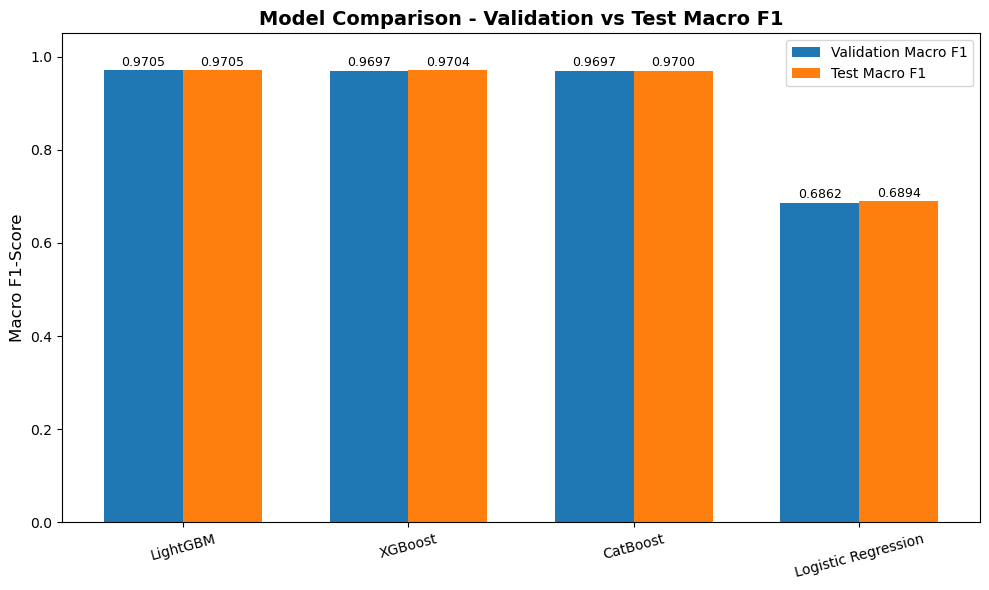


MODEL SELECTION
Best model based on Validation Macro F1: LightGBM
Validation Macro F1: 0.9705
Test Macro F1: 0.9705
Test High F1: 0.9403

FINAL TEST PERFORMANCE SUMMARY
LightGBM               Macro F1: 0.9705 | High F1: 0.9403
XGBoost                Macro F1: 0.9704 | High F1: 0.9397
CatBoost               Macro F1: 0.9700 | High F1: 0.9384
Logistic Regression    Macro F1: 0.6894 | High F1: 0.4202


In [41]:
validationMacroF1 = {
    'CatBoost': f1_score(
        validationTarget,
        catValidationPredictions,
        average='macro'
    ),
    'XGBoost': f1_score(
        validationTarget,
        xgbValidationPredictions,
        average='macro'
    ),
    'LightGBM': f1_score(
        validationTarget,
        lgbmValidationPredictions,
        average='macro'
    ),
    'Logistic Regression': f1_score(
        validationTarget,
        logisticRegressionValidationPredictions,
        average='macro'
    )
}

testMacroF1 = {
    'CatBoost': f1_score(
        testTarget,
        catTestPredictions,
        average='macro'
    ),
    'XGBoost': f1_score(
        testTarget,
        xgbTestPredictions,
        average='macro'
    ),
    'LightGBM': f1_score(
        testTarget,
        lgbmTestPredictions,
        average='macro'
    ),
    'Logistic Regression': f1_score(
        testTarget,
        logisticRegressionTestPredictions,
        average='macro'
    )
}

highClassIndex = labelEncoder.transform(['High'])[0]

validationHighF1 = {
    'CatBoost': f1_score(
        validationTarget,
        catValidationPredictions,
        labels=[highClassIndex],
        average='macro'
    ),
    'XGBoost': f1_score(
        validationTarget,
        xgbValidationPredictions,
        labels=[highClassIndex],
        average='macro'
    ),
    'LightGBM': f1_score(
        validationTarget,
        lgbmValidationPredictions,
        labels=[highClassIndex],
        average='macro'
    ),
    'Logistic Regression': f1_score(
        validationTarget,
        logisticRegressionValidationPredictions,
        labels=[highClassIndex],
        average='macro'
    )
}

testHighF1 = {
    'CatBoost': f1_score(
        testTarget,
        catTestPredictions,
        labels=[highClassIndex],
        average='macro'
    ),
    'XGBoost': f1_score(
        testTarget,
        xgbTestPredictions,
        labels=[highClassIndex],
        average='macro'
    ),
    'LightGBM': f1_score(
        testTarget,
        lgbmTestPredictions,
        labels=[highClassIndex],
        average='macro'
    ),
    'Logistic Regression': f1_score(
        testTarget,
        logisticRegressionTestPredictions,
        labels=[highClassIndex],
        average='macro'
    )
}

comparisonData = pd.DataFrame({
    'Validation Macro F1': validationMacroF1,
    'Test Macro F1': testMacroF1,
    'Validation High F1': validationHighF1,
    'Test High F1': testHighF1
})

comparisonData = comparisonData.sort_values(
    by='Validation Macro F1',
    ascending=False
)

print('\n' + '=' * 70)
print('FINAL MODEL COMPARISON')
print('=' * 70)

display(
    comparisonData.round(4)
)

plt.figure(figsize=(10, 6))

modelPositions = np.arange(
    len(comparisonData)
)

barWidth = 0.35

plt.bar(
    modelPositions - barWidth / 2,
    comparisonData['Validation Macro F1'],
    barWidth,
    label='Validation Macro F1'
)

plt.bar(
    modelPositions + barWidth / 2,
    comparisonData['Test Macro F1'],
    barWidth,
    label='Test Macro F1'
)

plt.xticks(
    modelPositions,
    comparisonData.index,
    rotation=15
)

plt.ylim(0, 1.05)

plt.ylabel(
    'Macro F1-Score',
    fontsize=12
)

plt.title(
    'Model Comparison - Validation vs Test Macro F1',
    fontsize=14,
    fontweight='bold'
)

plt.legend()

for position, score in enumerate(
    comparisonData['Validation Macro F1']
):
    plt.text(
        position - barWidth / 2,
        score + 0.01,
        f'{score:.4f}',
        ha='center',
        fontsize=9
    )

for position, score in enumerate(
    comparisonData['Test Macro F1']
):
    plt.text(
        position + barWidth / 2,
        score + 0.01,
        f'{score:.4f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

bestModelName = max(
    validationMacroF1,
    key=validationMacroF1.get
)

print('\n' + '=' * 70)
print('MODEL SELECTION')
print('=' * 70)

print(
    f'Best model based on Validation Macro F1: '
    f'{bestModelName}'
)

print(
    f'Validation Macro F1: '
    f'{validationMacroF1[bestModelName]:.4f}'
)

print(
    f'Test Macro F1: '
    f'{testMacroF1[bestModelName]:.4f}'
)

print(
    f'Test High F1: '
    f'{testHighF1[bestModelName]:.4f}'
)

print('\n' + '=' * 70)
print('FINAL TEST PERFORMANCE SUMMARY')
print('=' * 70)

for modelName in comparisonData.index:
    print(
        f'{modelName:<22} '
        f'Macro F1: {testMacroF1[modelName]:.4f} | '
        f'High F1: {testHighF1[modelName]:.4f}'
    )

FINAL ROC-AUC COMPARISON
CatBoost               Macro ROC-AUC: 0.9972
XGBoost                Macro ROC-AUC: 0.9976
LightGBM               Macro ROC-AUC: 0.9975
Logistic Regression    Macro ROC-AUC: 0.9297

BEST MODEL BASED ON ROC-AUC
Best ROC-AUC Model: XGBoost
Test Macro ROC-AUC: 0.9976


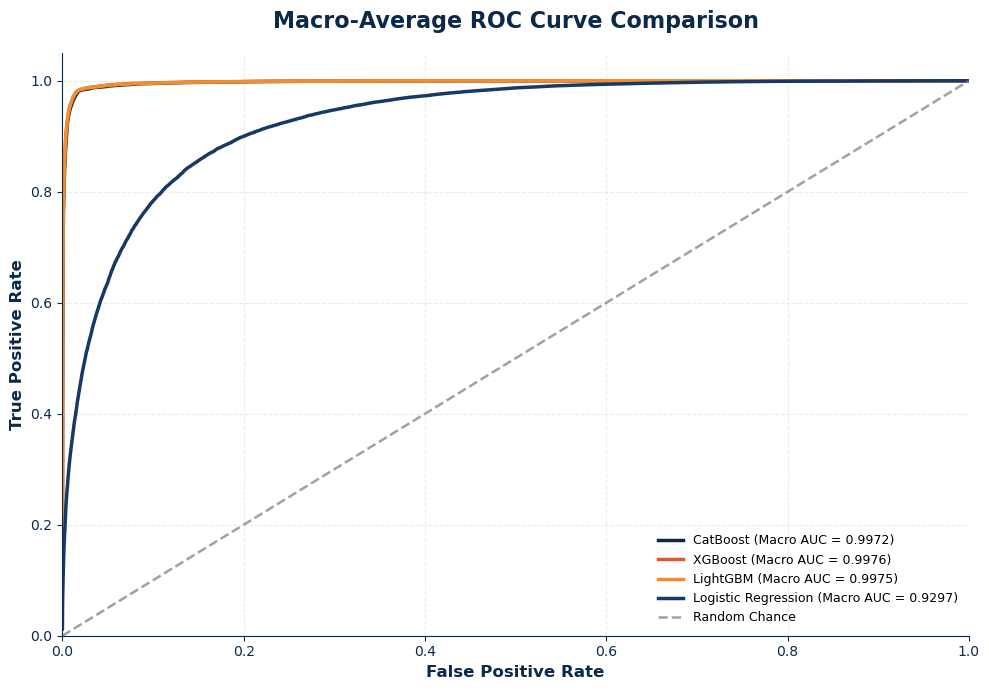

In [42]:
modelProbabilities = {
    'CatBoost': catModel.predict_proba(testFeatures),
    'XGBoost': xgbModel.predict_proba(testFeatures),
    'LightGBM': lgbmModel.predict_proba(testFeatures),
    'Logistic Regression': logisticRegressionModel.predict_proba(testFeatures)
}

testClasses = np.arange(
    len(labelEncoder.classes_)
)

testTargetBinary = label_binarize(
    testTarget,
    classes=testClasses
)

numberOfClasses = testTargetBinary.shape[1]

rocAucResults = {}

for modelName, predictionProbabilities in modelProbabilities.items():

    rocAucResults[modelName] = roc_auc_score(
        testTarget,
        predictionProbabilities,
        multi_class='ovr',
        average='macro'
    )

print("=" * 70)
print("FINAL ROC-AUC COMPARISON")
print("=" * 70)

for modelName, rocAucScore in rocAucResults.items():

    print(
        f"{modelName:<22} "
        f"Macro ROC-AUC: {rocAucScore:.4f}"
    )

bestRocAucModel = max(
    rocAucResults,
    key=rocAucResults.get
)

print("\n" + "=" * 70)
print("BEST MODEL BASED ON ROC-AUC")
print("=" * 70)

print(
    f"Best ROC-AUC Model: "
    f"{bestRocAucModel}"
)

print(
    f"Test Macro ROC-AUC: "
    f"{rocAucResults[bestRocAucModel]:.4f}"
)

figure, ax = plt.subplots(
    figsize=(10, 7),
    facecolor='white'
)

ax.set_facecolor('white')

modelColors = {
    'CatBoost': '#0B2A4A',
    'XGBoost': '#E4572E',
    'LightGBM': '#F28E2B',
    'Logistic Regression': '#163A63'
}

for modelName, predictionProbabilities in modelProbabilities.items():

    falsePositiveRates = {}
    truePositiveRates = {}

    for classIndex in range(numberOfClasses):

        falsePositiveRates[classIndex], truePositiveRates[classIndex], _ = roc_curve(
            testTargetBinary[:, classIndex],
            predictionProbabilities[:, classIndex]
        )

    allFalsePositiveRates = np.unique(
        np.concatenate(
            [
                falsePositiveRates[classIndex]
                for classIndex in range(numberOfClasses)
            ]
        )
    )

    meanTruePositiveRate = np.zeros_like(
        allFalsePositiveRates
    )

    for classIndex in range(numberOfClasses):

        meanTruePositiveRate += np.interp(
            allFalsePositiveRates,
            falsePositiveRates[classIndex],
            truePositiveRates[classIndex]
        )

    meanTruePositiveRate /= numberOfClasses

    macroRocAuc = rocAucResults[modelName]

    ax.plot(
        allFalsePositiveRates,
        meanTruePositiveRate,
        lw=2.5,
        color=modelColors[modelName],
        label=f'{modelName} (Macro AUC = {macroRocAuc:.4f})'
    )

ax.plot(
    [0, 1],
    [0, 1],
    '--',
    color='#7A7A7A',
    lw=1.8,
    label='Random Chance',
    alpha=0.7
)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

ax.set_xlabel(
    'False Positive Rate',
    fontsize=12,
    fontweight='bold',
    color='#0B2A4A'
)

ax.set_ylabel(
    'True Positive Rate',
    fontsize=12,
    fontweight='bold',
    color='#0B2A4A'
)

ax.set_title(
    'Macro-Average ROC Curve Comparison',
    fontsize=16,
    fontweight='bold',
    color='#0B2A4A',
    pad=18
)

ax.tick_params(
    axis='both',
    colors='#0B2A4A',
    labelsize=10
)

ax.grid(
    alpha=0.25,
    linestyle='--'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#0B2A4A')
ax.spines['bottom'].set_color('#0B2A4A')

ax.legend(
    loc='lower right',
    fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.show()

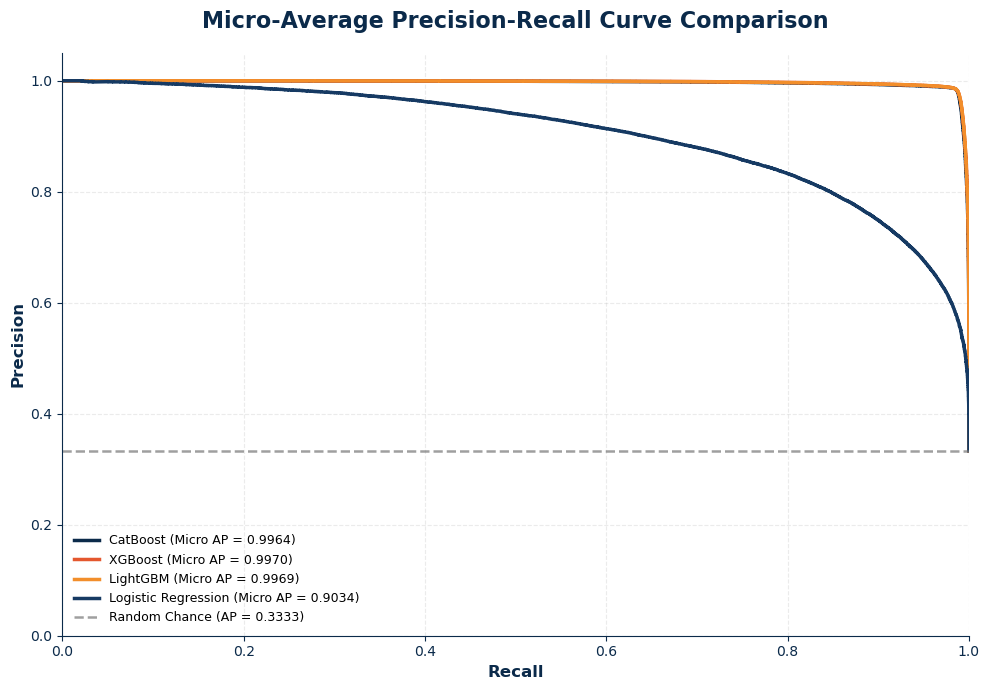

FINAL PRECISION-RECALL COMPARISON
CatBoost               Micro Average Precision: 0.9964
XGBoost                Micro Average Precision: 0.9970
LightGBM               Micro Average Precision: 0.9969
Logistic Regression    Micro Average Precision: 0.9034

BEST MODEL BASED ON PRECISION-RECALL
Best PR-AUC Model: XGBoost
Test Micro Average Precision: 0.9970


In [46]:
figure, ax = plt.subplots(
    figsize=(10, 7),
    facecolor='white'
)

ax.set_facecolor('white')

prAucResults = {}

modelColors = {
    'CatBoost': '#0B2A4A',
    'XGBoost': '#E4572E',
    'LightGBM': '#F28E2B',
    'Logistic Regression': '#163A63'
}

for modelName, predictionProbabilities in modelProbabilities.items():

    precision, recall, _ = precision_recall_curve(
        testTargetBinary.ravel(),
        predictionProbabilities.ravel()
    )

    microAveragePrecision = average_precision_score(
        testTargetBinary,
        predictionProbabilities,
        average='micro'
    )

    prAucResults[modelName] = microAveragePrecision

    ax.plot(
        recall,
        precision,
        lw=2.5,
        color=modelColors[modelName],
        label=f'{modelName} (Micro AP = {microAveragePrecision:.4f})'
    )

randomBaseline = (
    testTargetBinary.sum() /
    testTargetBinary.size
)

ax.axhline(
    randomBaseline,
    linestyle='--',
    color='#777777',
    lw=1.8,
    label=f'Random Chance (AP = {randomBaseline:.4f})',
    alpha=0.7
)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

ax.set_xlabel(
    'Recall',
    fontsize=12,
    fontweight='bold',
    color='#0B2A4A'
)

ax.set_ylabel(
    'Precision',
    fontsize=12,
    fontweight='bold',
    color='#0B2A4A'
)

ax.set_title(
    'Micro-Average Precision-Recall Curve Comparison',
    fontsize=16,
    fontweight='bold',
    color='#0B2A4A',
    pad=18
)

ax.tick_params(
    axis='both',
    colors='#0B2A4A',
    labelsize=10
)

ax.grid(
    alpha=0.25,
    linestyle='--'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#0B2A4A')
ax.spines['bottom'].set_color('#0B2A4A')

ax.legend(
    loc='lower left',
    fontsize=9,
    frameon=False
)

plt.tight_layout()
plt.show()

print("=" * 70)
print("FINAL PRECISION-RECALL COMPARISON")
print("=" * 70)

for modelName, averagePrecision in prAucResults.items():

    print(
        f"{modelName:<22} "
        f"Micro Average Precision: {averagePrecision:.4f}"
    )

bestPrModel = max(
    prAucResults,
    key=prAucResults.get
)

bestPrAuc = prAucResults[bestPrModel]

print()
print("=" * 70)
print("BEST MODEL BASED ON PRECISION-RECALL")
print("=" * 70)

print(
    f"Best PR-AUC Model: {bestPrModel}"
)

print(
    f"Test Micro Average Precision: "
    f"{bestPrAuc:.4f}"
)

CLASS ORDER
0 -> High
1 -> Low
2 -> Medium


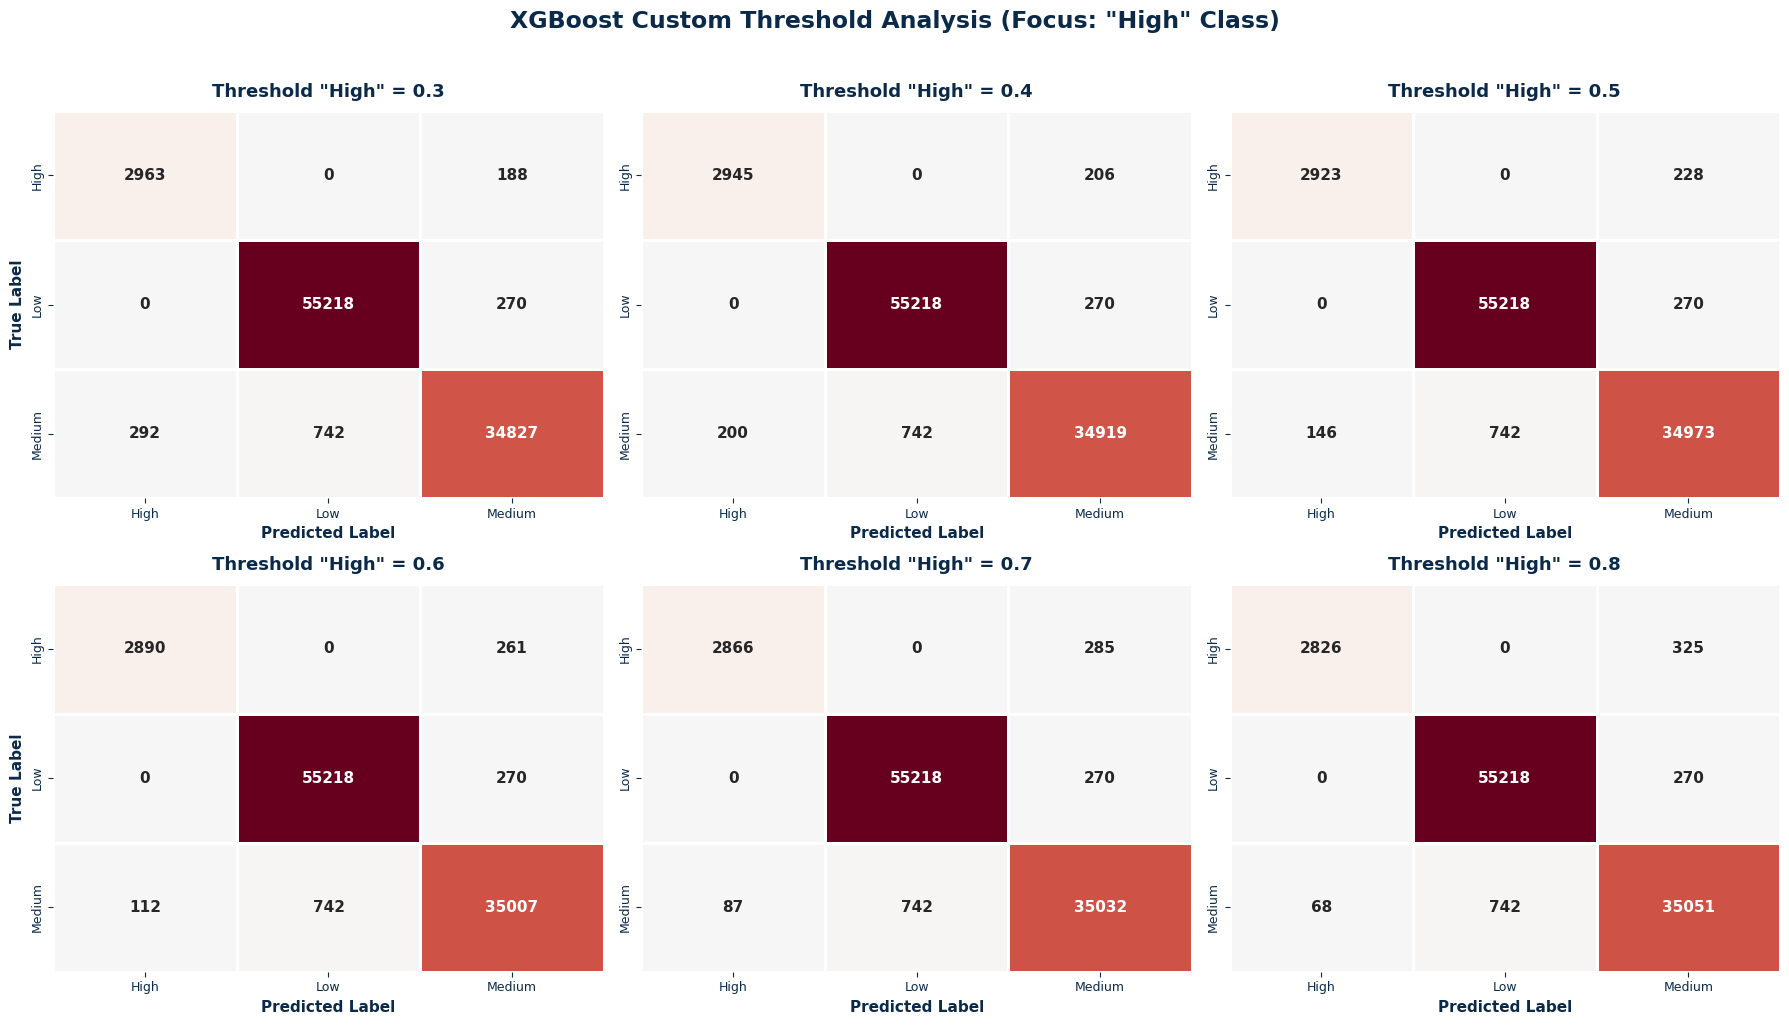

In [47]:
def applyCustomThreshold(probabilities, targetClassIndex, threshold):

    customPredictions = []

    for row in probabilities:

        if row[targetClassIndex] >= threshold:

            customPredictions.append(
                targetClassIndex
            )

        else:

            alternativeProbabilities = row.copy()

            alternativeProbabilities[targetClassIndex] = -1

            customPredictions.append(
                np.argmax(alternativeProbabilities)
            )

    return np.array(customPredictions)


targetClassIndex = labelEncoder.transform(
    ['High']
)[0]


classNames = labelEncoder.classes_.tolist()

print("=" * 70)
print("CLASS ORDER")
print("=" * 70)

for classIndex, className in enumerate(classNames):

    print(
        f"{classIndex} -> {className}"
    )


finalModelName = 'XGBoost'

finalModelProbabilities = modelProbabilities[
    finalModelName
]


thresholdsToTest = [
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8
]


classLabels = np.arange(
    len(classNames)
)


numberOfColumns = 3

numberOfRows = int(
    np.ceil(
        len(thresholdsToTest) /
        numberOfColumns
    )
)


figure, axes = plt.subplots(
    numberOfRows,
    numberOfColumns,
    figsize=(18, 5 * numberOfRows),
    facecolor='white'
)

axes = np.array(
    axes
).flatten()


for index, threshold in enumerate(
    thresholdsToTest
):

    customPredictions = applyCustomThreshold(
        finalModelProbabilities,
        targetClassIndex,
        threshold
    )

    confusionMatrix = confusion_matrix(
        testTarget,
        customPredictions,
        labels=classLabels
    )

    sns.heatmap(
        confusionMatrix,
        annot=True,
        fmt='d',
        cmap='RdBu_r',
        center=0,
        vmin=0,
        ax=axes[index],
        xticklabels=classNames,
        yticklabels=classNames,
        cbar=False,
        linewidths=1,
        linecolor='white',
        annot_kws={
            'fontsize': 11,
            'fontweight': 'bold'
        }
    )

    axes[index].set_title(
        f'Threshold "{classNames[targetClassIndex]}" = {threshold}',
        fontsize=13,
        fontweight='bold',
        color='#0B2A4A',
        pad=10
    )

    axes[index].set_xlabel(
        'Predicted Label',
        fontsize=11,
        fontweight='bold',
        color='#0B2A4A'
    )

    if index % numberOfColumns == 0:

        axes[index].set_ylabel(
            'True Label',
            fontsize=11,
            fontweight='bold',
            color='#0B2A4A'
        )

    else:

        axes[index].set_ylabel('')

    axes[index].tick_params(
        axis='both',
        colors='#0B2A4A',
        labelsize=9
    )


for index in range(
    len(thresholdsToTest),
    len(axes)
):

    figure.delaxes(
        axes[index]
    )


plt.suptitle(
    f'XGBoost Custom Threshold Analysis '
    f'(Focus: "{classNames[targetClassIndex]}" Class)',
    fontsize=17,
    fontweight='bold',
    color='#0B2A4A',
    y=1.02
)

plt.tight_layout()

plt.show()

TOP 20 XGBOOST FEATURES
 1. Crop_Growth_Stage_Sowing                 0.209279
 2. Mulching_Used_Yes                        0.135162
 3. Crop_Growth_Stage_Harvest                0.134313
 4. Soil_Moisture                            0.122873
 5. Crop_Growth_Stage_Vegetative             0.069137
 6. Temperature_C                            0.067405
 7. Wind_Speed_kmh                           0.058130
 8. Rainfall_mm                              0.028858
 9. Water_Source_River                       0.018222
10. Water_Source_Rainwater                   0.014148
11. Water_Source_Reservoir                   0.010781
12. Crop_Type_Maize                          0.009189
13. Irrigation_Type_Sprinkler                0.009155
14. Soil_Type_Sandy                          0.008841
15. Irrigation_Type_Rainfed                  0.008440
16. Crop_Type_Sugarcane                      0.008043
17. Region_East                              0.007740
18. Region_South                             0.007335
19. 

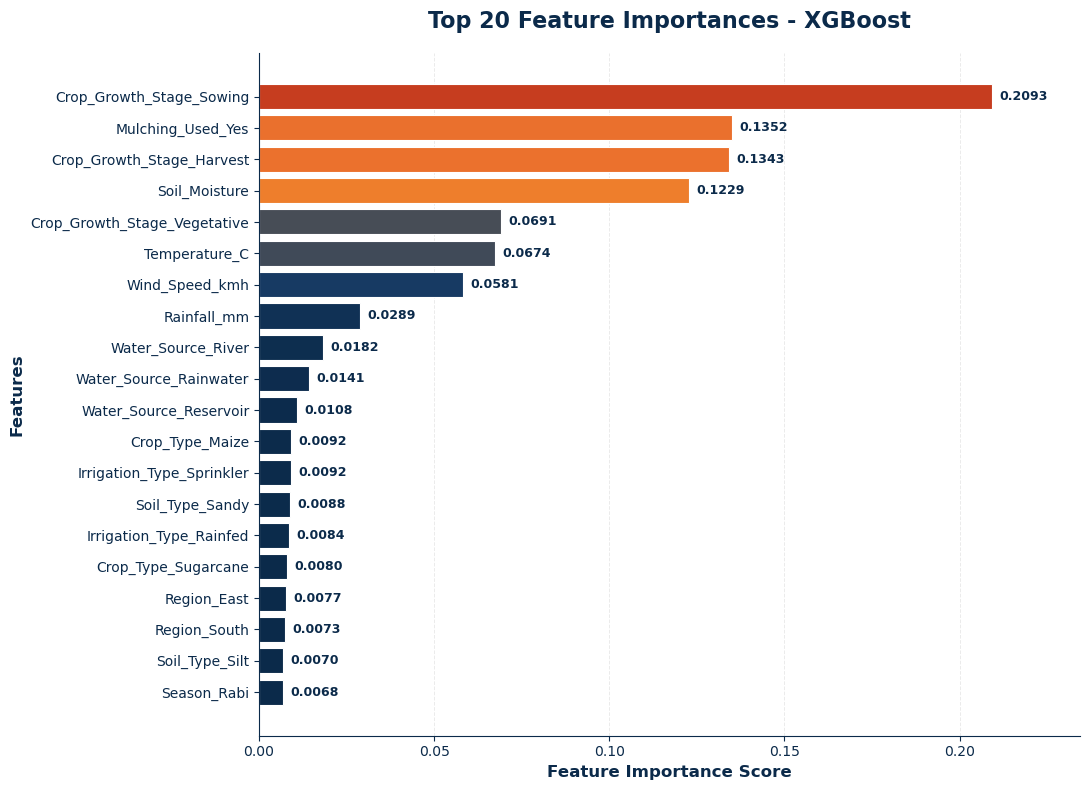

In [48]:
featureImportance = pd.Series(
    xgbModel.feature_importances_,
    index=trainFeaturesResampled.columns
).sort_values(
    ascending=False
)

topFeatures = featureImportance.head(20)

print("=" * 70)
print("TOP 20 XGBOOST FEATURES")
print("=" * 70)

for rank, (featureName, importanceScore) in enumerate(
    topFeatures.items(),
    start=1
):

    print(
        f"{rank:2d}. {featureName:<40} "
        f"{importanceScore:.6f}"
    )

figure, ax = plt.subplots(
    figsize=(11, 8),
    facecolor='white'
)

ax.set_facecolor('white')

featureValues = topFeatures.values

normalizedValues = (
    (featureValues - featureValues.min()) /
    (featureValues.max() - featureValues.min())
)

from matplotlib.colors import LinearSegmentedColormap

gradientColors = LinearSegmentedColormap.from_list(
    'navyOrangeRed',
    [
        '#0B2A4A',
        '#163A63',
        '#F28E2B',
        '#E4572E',
        '#C63D1F'
    ]
)

barColors = gradientColors(
    normalizedValues
)

bars = ax.barh(
    topFeatures.index,
    topFeatures.values,
    color=barColors,
    edgecolor='white',
    linewidth=0.8
)

ax.invert_yaxis()

ax.set_title(
    'Top 20 Feature Importances - XGBoost',
    fontsize=16,
    fontweight='bold',
    color='#0B2A4A',
    pad=18
)

ax.set_xlabel(
    'Feature Importance Score',
    fontsize=12,
    fontweight='bold',
    color='#0B2A4A'
)

ax.set_ylabel(
    'Features',
    fontsize=12,
    fontweight='bold',
    color='#0B2A4A'
)

ax.tick_params(
    axis='both',
    colors='#0B2A4A',
    labelsize=10
)

ax.grid(
    axis='x',
    linestyle='--',
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['left'].set_color('#0B2A4A')
ax.spines['bottom'].set_color('#0B2A4A')

for bar, importanceScore in zip(
    bars,
    topFeatures.values
):

    ax.text(
        bar.get_width() + (
            topFeatures.max() * 0.01
        ),
        bar.get_y() + bar.get_height() / 2,
        f'{importanceScore:.4f}',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='#0B2A4A'
    )

ax.set_xlim(
    0,
    topFeatures.max() * 1.12
)

plt.tight_layout()
plt.show()

In [49]:
modelPath = os.path.join(
    '..',
    'xgboost_model.pkl'
)

columnsPath = os.path.join(
    '..',
    'model_columns.pkl'
)

joblib.dump(
    xgbModel,
    modelPath
)

modelColumns = list(
    trainFeaturesResampled.columns
)

joblib.dump(
    modelColumns,
    columnsPath
)

print("=" * 70)
print("FINAL MODEL SAVED SUCCESSFULLY")
print("=" * 70)

print(
    f"Model saved   → {os.path.abspath(modelPath)}"
)

print(
    f"Columns saved → {os.path.abspath(columnsPath)}"
)

print(
    f"\nTotal columns in model: {len(modelColumns)}"
)

FINAL MODEL SAVED SUCCESSFULLY
Model saved   → /Users/thekumarsai/Developer/smart-farm-flask/xgboost_model.pkl
Columns saved → /Users/thekumarsai/Developer/smart-farm-flask/model_columns.pkl

Total columns in model: 35


## Model Training & Deployment — Final Status

After completing all the notebook cells:

1. The final **XGBoost model** and **model feature columns** are saved in the project root:
   - `xgboost_model.pkl`
   - `model_columns.pkl`

2. Before deployment, the model must pass the final evaluation checks:
   - No significant overfitting
   - No significant underfitting
   - Balanced performance across all three classes
   - Acceptable Macro F1-score
   - Final performance verified on the untouched test set
   - Final ROC-AUC and Precision-Recall performance verified on the untouched test set

3. Based on the final evaluation:
   - **XGBoost** is the selected final model.
   - Test Macro ROC-AUC: **0.9976**
   - Test Micro Average Precision: **0.9970**

4. Once the final model is validated, start the Flask server:

```bash
python app.py